In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

### Partie 1 – Génération du dataset 

In [3]:
np.random.seed(42)  # pour la reproductibilité

# 1) Génération des 1000 valeurs pour chaque variable
temperature = np.random.normal(loc=25, scale=4, size=1000)          
humidite = np.random.uniform(low=30, high=80, size=1000)            
occupants = np.random.randint(low=1, high=50, size=1000)            


##### 2) Déterminer la variable consommation avec la formule suivante : 

In [4]:
bruit = np.random.normal(loc=0, scale=10, size=1000)              
consommation = (
    50                     
    + 5 * temperature     
    + 1.5 * humidite        
    + 4 * occupants       
    + bruit             
)

##### 3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au format (float32) optimisé pour les calculs 

In [5]:
X = np.column_stack((temperature, humidite, occupants)).astype(np.float32)

##### 4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [6]:
y = consommation.astype(np.float32)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (1000, 3)
Shape de y : (1000,)


### Partie 2 – Découpage Train/Test

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)

Shape X_train : (800, 3)
Shape X_test  : (200, 3)
Shape y_train : (800,)
Shape y_test  : (200,)


### Partie 3 – Création du modèle

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

# 1) Construction du modèle séquentiel
model = keras.Sequential([
    layers.Input(shape=(3,)),                      
    layers.Dense(16, activation='relu'),            
    layers.Dense(8, activation='relu'),             
    layers.Dense(1)                                 
])

##### 2) Afficher un résumé textuel de l'architecture du réseau de neurones. 

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

### Partie 4 – Compilation du modèle 

In [10]:
model.compile(
    optimizer='adam',           
    loss='mse',                 
    metrics=['mae']             
)

### Partie 5 – Entraînement du modèle 

In [11]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   
    epochs=50,              
    batch_size=16,         
    verbose=0
)

##### 2) Examiner le contenu de history

In [12]:
print("Clés disponibles :", list(history.history.keys()))
print("Nombre d'époques enregistrées :", len(history.history['loss']))

Clés disponibles : ['loss', 'mae', 'val_loss', 'val_mae']
Nombre d'époques enregistrées : 50


##### 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage 

In [13]:
print(history.history.values())

dict_values([[127431.0, 98716.1015625, 64648.3359375, 28179.32421875, 7731.6337890625, 2711.463623046875, 2000.8701171875, 1581.0091552734375, 1229.5352783203125, 942.0187377929688, 715.7952270507812, 526.9010620117188, 292.6241455078125, 220.7516632080078, 191.2164764404297, 178.987548828125, 171.56228637695312, 167.23545837402344, 162.73683166503906, 160.47103881835938, 157.20358276367188, 157.74095153808594, 154.05581665039062, 153.06588745117188, 151.3147430419922, 150.49203491210938, 149.98944091796875, 149.255126953125, 148.87271118164062, 148.86813354492188, 148.3389434814453, 148.90769958496094, 145.93490600585938, 145.3473358154297, 145.29287719726562, 144.04251098632812, 145.5823211669922, 144.57162475585938, 142.97055053710938, 142.84259033203125, 142.48558044433594, 141.9228973388672, 142.29159545898438, 143.12083435058594, 142.29417419433594, 142.72779846191406, 143.6497039794922, 143.5961151123047, 143.15467834472656, 140.3471221923828], [350.88800048828125, 307.987365722

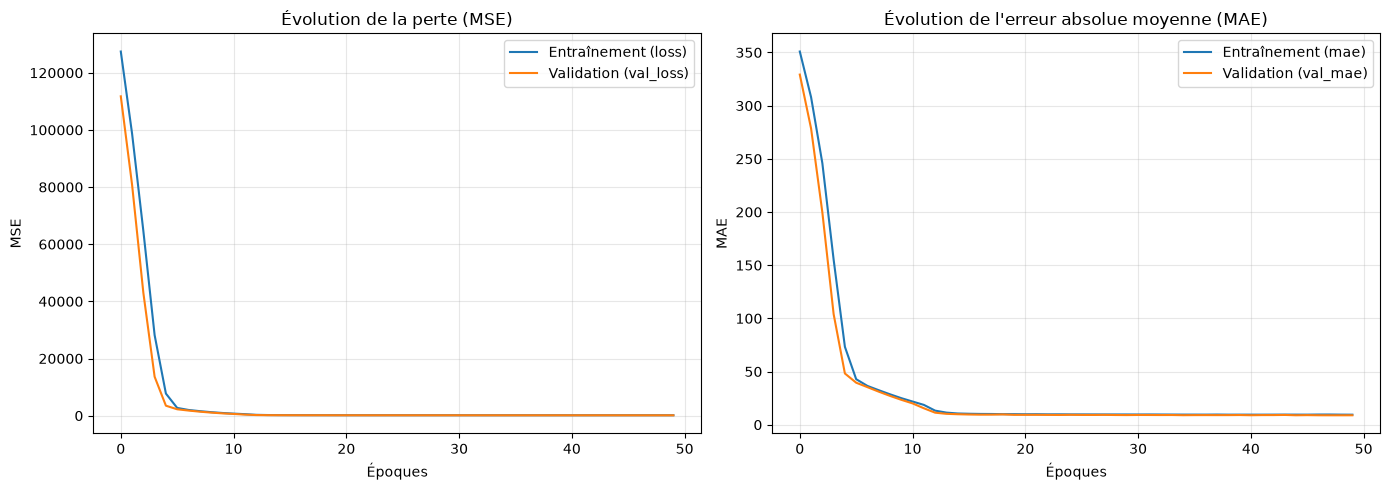

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Loss (MSE)
axes[0].plot(history.history['loss'], label='Entraînement (loss)')
axes[0].plot(history.history['val_loss'], label='Validation (val_loss)')
axes[0].set_title('Évolution de la perte (MSE)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : MAE
axes[1].plot(history.history['mae'], label='Entraînement (mae)')
axes[1].plot(history.history['val_mae'], label='Validation (val_mae)')
axes[1].set_title('Évolution de l\'erreur absolue moyenne (MAE)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***interpretation du resultat*** : 
Chute quasi verticale (époques 0 à 6) les poids partent d'une initialisation aléatoire, donc les toutes premières prédictions sont très mauvaises (MSE ~140 000, MAE ~370). Le modèle corrige rapidement ses erreurs les plus grossières dès les premières époques.

Palier et convergence (à partir de l'époque ~10) .les deux courbes s'aplatissent et continuent de décroître très lentement : le modèle affine ses poids finement, les gains deviennent marginaux.

Courbes train et validation quasi superposées, sans écart qui se creuse .c'est le signe qu'il n'y a pas de surapprentissage (overfitting) : le modèle généralise bien, il n'apprend pas "par cœur" les données d'entraînement.

MAE final autour de 9-10 en moyenne, les prédictions s'écartent d'environ 9 à 10 unités de consommation par rapport à la réalité. C'est cohérent avec le bruit aléatoire (écart-type de 10) injecté volontairement dans le dataset : le modèle a essentiellement atteint la limite de ce qu'il est possible de prédire, le reste de l'erreur étant du bruit irréductible.